In [1]:
from learn_to_infer import Worker
from task import probabilistic_task
import pandas as pd
import torch
import numpy as np

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


In [4]:
index = 2

self = Worker(
    probabilistic_task(),
    "results/source/saved_models",
    "rnn_pf_id{0}".format(index),
    optimizer="Adam",
    init_type="xavier",
    episode_count_max=5e4,
    num_units=32,
    learn_emission=False
)

self.load_model()

In [10]:
# learn task A
np.random.seed(0)
#self.env.reset(num_trials=500, num_steps=5, num_tasks=1, reset_probas=True, tau=0.01, variable_length=False)
self.env.generate_test_task(num_tasks=10, num_trials=500, num_steps=5, probas=None, variable_length=False, tau=0.01)
result = self.evaluate()

In [14]:
result['emission_probs'].shape

torch.Size([10, 500, 4])

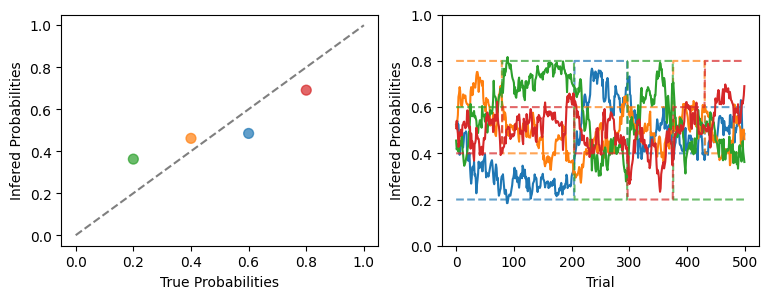

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 3))
plt.subplot(1, 2, 1)
plt.scatter(result['probas'][0, -1], result['emission_probs'][0, -1].detach().numpy(), alpha=0.7, color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"], s=50)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='x=y')
plt.ylabel('Infered Probabilities')
plt.xlabel('True Probabilities')
plt.subplot(1, 2, 2)
for i in range(4):
    plt.plot(result['emission_probs'].detach().numpy()[0, :, i], color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"][i])
    plt.plot(result['probas'][0, :, i], linestyle='--', alpha=0.7, color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"][i])
plt.ylabel('Infered Probabilities')
plt.xlabel('Trial')
plt.gca().set_ylim(0, 1)
#plt.savefig('figures/WP_0.pdf')
plt.show()

(0.0, 1.0)

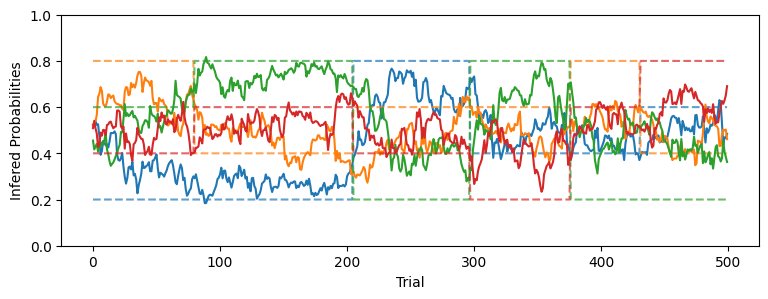

In [17]:
plt.figure(figsize=(9, 3))
for i in range(4):
    plt.plot(result['emission_probs'].detach().numpy()[0, :, i], color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"][i])
    plt.plot(result['probas'][0, :, i], linestyle='--', alpha=0.7, color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"][i])
plt.ylabel('Infered Probabilities')
plt.xlabel('Trial')
plt.gca().set_ylim(0, 1)
#plt.savefig('figures/WP_trials_example.pdf')
plt.gca().set_ylim(0, 1)

### performances as a function of the sequence length

In [18]:
# performances as a function of the sequence length
nb_agents = 10
nb_simuls = 1
performances = np.zeros((nb_agents, nb_simuls, 3))

for idx_agent in range(nb_agents):
    self = Worker(
        probabilistic_task(),
        "results/source/saved_models",
        "rnn_pf_id{0}".format(idx_agent + 1),
        optimizer="Adam",
        init_type="xavier",
        episode_count_max=2e4,
        num_units=32,
    )

    self.load_model()

    np.random.seed(idx_agent)
    self.env.reset(num_tasks=nb_simuls, num_trials=500, num_steps=3, reset_probas=True, variable_length=True, tau=0.0)
    result = self.evaluate()

    # 3 steps
    self.env.reset(num_tasks=nb_simuls, num_trials=500, num_steps=3, reset_probas=False, variable_length=False)
    result1 = self.evaluate(rnn_state=result['rnn_state'], update_state=False)

    # 6 steps
    self.env.reset(num_tasks=nb_simuls, num_trials=500, num_steps=6, reset_probas=False, variable_length=False)
    result2 = self.evaluate(rnn_state=result['rnn_state'], update_state=False)

    # 9 steps
    self.env.reset(num_tasks=nb_simuls, num_trials=500, num_steps=9, reset_probas=False, variable_length=False)
    result3 = self.evaluate(rnn_state=result['rnn_state'], update_state=False)

    # save results
    performances[idx_agent,:, 0] = ((result1['rewarded'] * (result1['logodds'].sign()).detach()) > 0).float().mean(axis=-1)
    performances[idx_agent,:, 1] = ((result2['rewarded'] * (result2['logodds'].sign()).detach()) > 0).float().mean(axis=-1)
    performances[idx_agent,:, 2] = ((result3['rewarded'] * (result3['logodds'].sign()).detach()) > 0).float().mean()

performances = np.mean(performances, axis=1)


FileNotFoundError: [Errno 2] No such file or directory: 'results/source/saved_models/rnn_pf_id1_init_xavier_optim_Adam_episodeNbMax_20000_numUnits_32_learnEmission_True/model-20000.pth'

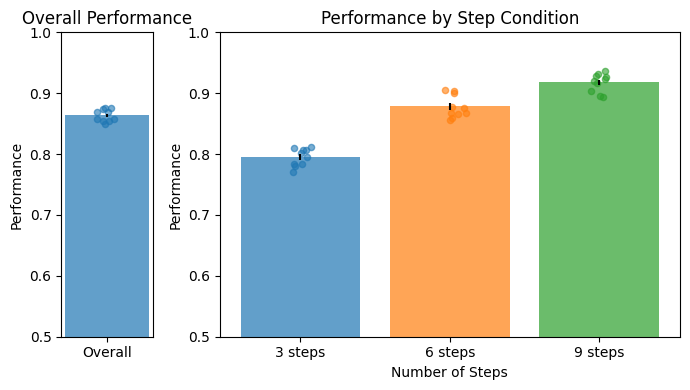

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate overall mean and sem for the single-bar plot
overall_performances = np.mean(performances, axis=1)
overall_mean = np.mean(overall_performances)
overall_std = np.std(overall_performances)
overall_sem = overall_std / np.sqrt(overall_performances.shape[0])

# Calculate means and standard errors for each step condition
means = np.mean(performances, axis=0)
stds = np.std(performances, axis=0)
sems = stds / np.sqrt(performances.shape[0])

x_pos = np.arange(len(means))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

fig, axs = plt.subplots(1, 2, figsize=(7, 4), gridspec_kw={'width_ratios': [1, 5]})

# First subplot: overall performance (single bar)
axs[0].bar([0], [overall_mean], yerr=[overall_sem], capsize=0, alpha=0.7, color='#1f77b4')
for i in range(len(overall_performances)):
    x_jitter = np.random.normal(0, 0.05)
    axs[0].scatter(x_jitter, overall_performances[i], alpha=0.6, s=20, color='#1f77b4')
axs[0].set_ylabel('Performance')
axs[0].set_xticks([0])
axs[0].set_xticklabels(['Overall'])
axs[0].set_ylim(0.5, 1)
axs[0].set_title('Overall Performance')

# Second subplot: performance by step condition (bar + scatter)
bars = axs[1].bar(x_pos, means, yerr=sems, capsize=0, alpha=0.7, color=colors)
for i in range(len(means)):
    x_jitter = np.random.normal(i, 0.05, performances.shape[0])
    axs[1].scatter(x_jitter, performances[:, i], alpha=0.6, s=20, color=colors[i])
axs[1].set_xlabel('Number of Steps')
axs[1].set_ylabel('Performance')
axs[1].set_title('Performance by Step Condition')
axs[1].set_xticks(x_pos)
axs[1].set_xticklabels(['3 steps', '6 steps', '9 steps'])
axs[1].set_ylim(0.5, 1)

plt.tight_layout()
#plt.savefig('figures/WP_nb_steps.pdf')
plt.show()

### subjective reliabilities

In [18]:
# performances as a function of the sequence length
nb_agents = 10
nb_simuls = 20
emission_probs = np.zeros((nb_agents, nb_simuls, 500, 4))

for idx_agent in range(nb_agents):
    self = Worker(
        probabilistic_task(),
        "results/source/saved_models",
        "rnn_pf_id{0}".format(idx_agent + 1),
        optimizer="Adam",
        init_type="xavier",
        episode_count_max=2e4,
        num_units=32,
    )

    self.load_model()

    np.random.seed(idx_agent)
    self.env.reset(num_tasks=nb_simuls, num_trials=500, num_steps=5, reset_probas=True, variable_length=False, tau=0.0)
    result1 = self.evaluate()
    index_sorted = np.argsort(np.unique(self.env.probas, axis=1).squeeze(), axis=1)
    emission_probs[idx_agent] = np.swapaxes(result1['emission_probs'][np.arange(nb_simuls)[:, None],: , index_sorted].detach().numpy(), 1, 2)

emission_probs = np.mean(emission_probs, axis=1)

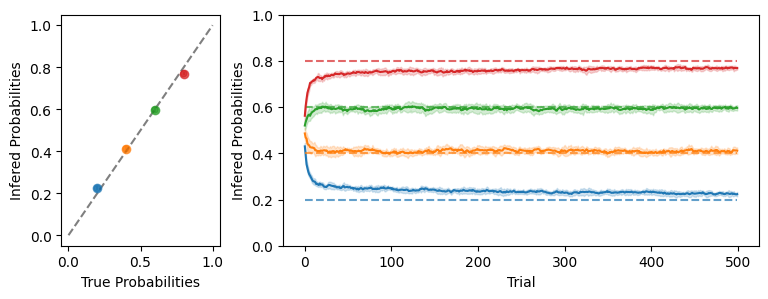

: 

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(9, 3), gridspec_kw={'width_ratios': [1, 3]})
pmeans = emission_probs[:, -1].mean(axis=0)
pstds = emission_probs[:, -1].std(axis=0)
axs[0].scatter(np.array([0.2, 0.4, 0.6, 0.8]), pmeans, alpha=0.7, color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"], s=20)
for i, color in enumerate(["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]):
    axs[0].errorbar(np.array([0.2, 0.4, 0.6, 0.8])[i], pmeans[i], yerr=pstds[i], alpha=0.7, color=color, fmt='o')
axs[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='x=y')
axs[0].set_ylabel('Infered Probabilities')
axs[0].set_xlabel('True Probabilities')
for i in range(4):
    pmean = emission_probs.mean(axis=0)[:, i]
    pstd = emission_probs.std(axis=0)[:, i]
    axs[1].plot(pmean, color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"][i])
    axs[1].fill_between(np.arange(500), pmean - pstd, pmean + pstd, alpha=0.2, color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"][i])
    p = np.array([0.2, 0.4, 0.6, 0.8])[i]
    axs[1].plot(p * np.ones(500), linestyle='--', alpha=0.7, color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"][i])
axs[1].set_ylabel('Infered Probabilities')
axs[1].set_xlabel('Trial')
axs[1].set_ylim(0, 1)
#plt.savefig('figures/WP_learning.pdf')
plt.show()

### with emission reversals

In [ ]:
self.env.reset(num_tasks=1, num_trials=500, num_steps=5, reset_probas=True, variable_length=False, tau=0.025)
env_probas = np.zeros([20, 500, 4])
for i in range(20):
    np.random.seed(i)
    itrial = np.random.randint(100, 400)
    env_probas[i, :itrial] = self.env.probas[0, 0]
    env_probas[i, itrial:] = self.env.probas[0, -1]
self.env.probas = env_probas

In [146]:
# performances as a function of the sequence length
nb_agents = 30
nb_simuls = 20
emission_probs = np.zeros((nb_agents, nb_simuls, 150, 4))
ground_truth_probas = np.zeros((nb_agents, nb_simuls, 150, 4))

for idx_agent in range(nb_agents):
    self = Worker(
        probabilistic_task(),
        "results/source/saved_models",
        "rnn_pf_id{0}".format(idx_agent + 1),
        optimizer="Adam",
        init_type="xavier",
        episode_count_max=2e4,
        num_units=32,
        integration="optimal",
        loss_type="BCE",
    )

    self.load_model()

    np.random.seed(2)
    self.env.reset(num_tasks=nb_simuls, num_trials=500, num_steps=5, reset_probas=True, variable_length=False, tau=0.025)
    env_probas = np.zeros([20, 500, 4])
    itrials = np.zeros([nb_simuls, 150], dtype=int)
    for i in range(nb_simuls):
        np.random.seed(i)
        itrial = np.random.randint(100, 400)
        itrials[i] = np.arange(itrial - 50, itrial + 100)
        env_probas[i, :itrial] = self.env.probas[0, 0]
        env_probas[i, itrial:] = self.env.probas[0, -1]
    self.env.probas = env_probas    
    self.env.reset(num_tasks=nb_simuls, num_trials=500, num_steps=5, reset_probas=False, variable_length=False, tau=None)
    
    result1 = self.evaluate()
    emission_probs[idx_agent] = result1['emission_probs'][np.arange(nb_simuls)[:, None], itrials].detach().numpy()
    ground_truth_probas[idx_agent] = result1['probas'][np.arange(nb_simuls)[:, None], itrials]

emission_probs = np.mean(emission_probs, axis=1)
ground_truth_probas = np.mean(ground_truth_probas, axis=1)

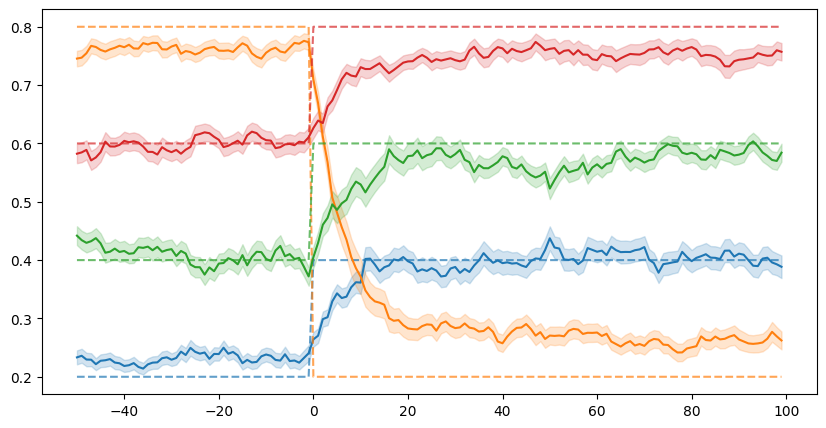

In [148]:
plt.figure(figsize=(10, 5))
mean_emission_probs = emission_probs.mean(axis=0)
std_emission_probs = emission_probs.std(axis=0)
mean_ground_truth_probas = ground_truth_probas.mean(axis=0)
xx = np.arange(-50, 100)
for i in range(4):
    plt.plot(xx, mean_emission_probs[:, i], color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"][i])
    plt.plot(xx, mean_ground_truth_probas[:, i], linestyle='--', alpha=0.7, color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"][i])
    plt.fill_between(xx, mean_emission_probs[:, i] - std_emission_probs[:, i], mean_emission_probs[:, i] + std_emission_probs[:, i], alpha=0.2, color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"][i])
plt.savefig('figures/WP_reversal.pdf')
plt.show()

In [141]:
emission_probs.shape

(30, 150, 4)

In [65]:
outlist = []
nb_simul = 100
for nb_steps in [4, 8]:
    for i_simul in range(nb_simul):
        self.env.reset(num_trials=200, num_steps=1, num_tasks=1, reset_probas=True)
        result = self.evaluate()        
        self.env.reset(num_trials=200, num_steps=nb_steps, reset_probas=False, cond='Astar')
        test_result = self.evaluate(rnn_state=result['rnn_state'])
        max_perf = ((test_result['greedy'] * 2 - 1) == test_result['rewarded']).float().mean()
        agent_perf = ((test_result['logodds']).sign().detach() == test_result['rewarded']).float().mean()
        outlist.append([nb_steps, i_simul, float(max_perf), float(agent_perf)])
outdf = pd.DataFrame(outlist, columns=['nb_steps', 'i_simul', 'max_perf', 'agent_perf'])

/Users/csmfindling/Documents/Postdoc-Geneva/reliability_VW/reasoning/rnns/task.py:14: FutureWarning: arrays to stack must be passed as a "sequence" type such as list or tuple. Support for non-sequence iterables such as generators is deprecated as of NumPy 1.16 and will raise an error in the future.
  cues_presented = np.vstack(np.random.choice(list(cues) * (num_trials // len(cues)), size=num_trials, replace=False) for _ in range(num_tasks))


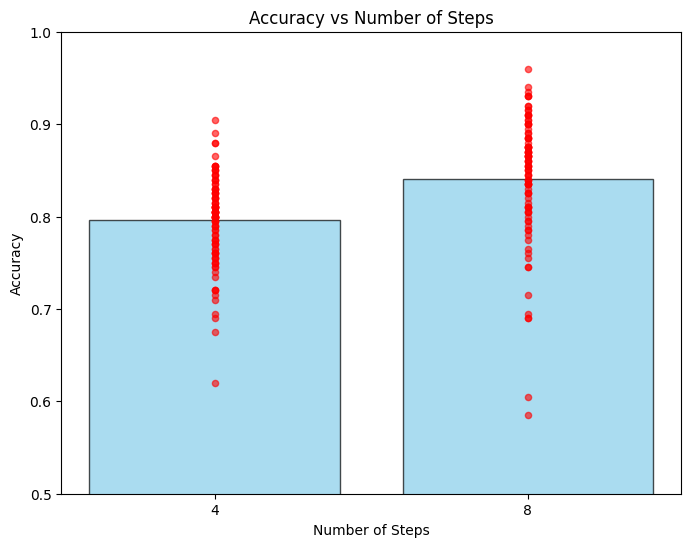

nb_steps
4    0.79600
8    0.84015
Name: agent_perf, dtype: float64

In [66]:
import matplotlib.pyplot as plt

# Group by number of steps and calculate mean accuracy
grouped = outdf.groupby('nb_steps')['agent_perf'].mean()

# Create bar plot
plt.figure(figsize=(8, 6))
bars = plt.bar([0, 1], grouped.values, alpha=0.7, color='skyblue', edgecolor='black')

# Add individual points
for pos,nb_steps in zip([0, 1], outdf['nb_steps'].unique()):
    step_data = outdf[outdf['nb_steps'] == nb_steps]['agent_perf']
    x_positions = [pos] * len(step_data)
    plt.scatter(x_positions, step_data, alpha=0.6, color='red', s=20)

plt.xlabel('Number of Steps')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Number of Steps')
plt.xticks([0, 1], ['4', '8'])
plt.ylim(0.5, 1.)
plt.show()

# Also display the grouped means
grouped

In [161]:
import pickle
[logodd_sequence_across_subjects_8, logodd_sequence_across_subjects_4] = pickle.load(
    open('/Users/csmfindling/Documents/Postdoc-Geneva/reliability_VW/reasoning/rnns/subject_tasks/subj_tasks.pkl', 'rb')
)

In [ ]:
tasks_8 = logodd_sequence_across_subjects_8[np.random.choice(np.arange(logodd_sequence_across_subjects_8.shape[0]), size=200, replace=False)]

array([[2, 0, 0, ..., 0, 3, 4],
       [4, 4, 3, ..., 2, 4, 4],
       [2, 0, 3, ..., 0, 3, 2],
       ...,
       [4, 2, 0, ..., 3, 2, 0],
       [3, 4, 3, ..., 0, 3, 2],
       [3, 3, 3, ..., 3, 2, 4]])

In [163]:
logodd_sequence_across_subjects_8.shape

(35, 120, 8)

In [227]:
from tqdm import tqdm
outlist = []
probalist = []
nb_simul = 35

for idx_simul in tqdm(range(1, 21)):

    self = Worker(
        probabilistic_task(),
        "results/source/saved_models",
        "rnn_pf_id{0}".format(idx_simul),
        "white",
        0.,
        nb_samples=-1,
        train_task="A",
        optimizer="Adam",
        init_type="xavier",
        episode_count_max=2e4,
        num_units=32,
        integration="optimal",
        loss_type="BCE",
        learn_variabilities=False
    )

    self.load_model()

    for nb_steps in [4, 8]:
        for i_simul in range(nb_simul):
            np.random.seed(i_simul * 2)
            torch.manual_seed(i_simul * 2)
            self.env.reset(num_trials=200, num_steps=1, num_tasks=1, reset_probas=True)
            result = self.evaluate()        
            
            #self.env.reset(num_trials=200, num_steps=nb_steps, reset_probas=False, cond='Astar')
            tasks = logodd_sequence_across_subjects_8[idx_simul] if nb_steps == 8 else logodd_sequence_across_subjects_4[idx_simul]      
            proba_tasks = np.round(1./(1. + np.exp(-tasks)), 1)
            squeezed_probas = np.round(self.env.probas.squeeze(), 2)
            sorter = np.argsort(squeezed_probas)
            self.env.context = torch.from_numpy(sorter[np.searchsorted(squeezed_probas[sorter], proba_tasks)])
            self.env.num_trials = 120
            self.env.num_steps = nb_steps
            self.env.cond = 'Astar'
            test_result = self.evaluate(rnn_state=result['rnn_state'])
            test_result['greedy'] = (tasks.sum(axis=1) > 0) * 1
            test_result['rewarded'] = (np.random.rand(120) < 1./(1. + np.exp(-tasks.sum(axis=1)))) * 2 - 1
            max_perf = ((test_result['greedy'] * 2 - 1) == test_result['rewarded']).mean()
            agent_perf = ((test_result['logodds']).squeeze().sign().detach().numpy() == test_result['rewarded']).mean()
            outlist.append([nb_steps, idx_simul, i_simul, float(max_perf), float(agent_perf)])    

            sorted_indices = np.argsort(result['probas'].squeeze())
            sorted_emissions = result['emission_probs'][sorted_indices]
            sorted_probas = result['probas'].squeeze()[sorted_indices]
            for i in range(len(sorted_emissions)):
                probalist.append([nb_steps, idx_simul, i_simul, float(sorted_emissions[i]), sorted_probas[i]])

outdf = pd.DataFrame(outlist, columns=['nb_steps', 'idx_simul', 'i_simul', 'max_perf', 'agent_perf'])
probadf = pd.DataFrame(probalist, columns=['nb_steps', 'idx_simul', 'i_simul', 'emission_probs', 'probas'])

  0%|          | 0/20 [00:00<?, ?it/s]/Users/csmfindling/Documents/Postdoc-Geneva/reliability_VW/reasoning/rnns/task.py:14: FutureWarning: arrays to stack must be passed as a "sequence" type such as list or tuple. Support for non-sequence iterables such as generators is deprecated as of NumPy 1.16 and will raise an error in the future.
  cues_presented = np.vstack(np.random.choice(list(cues) * (num_trials // len(cues)), size=num_trials, replace=False) for _ in range(num_tasks))
100%|██████████| 20/20 [00:43<00:00,  2.15s/it]


In [228]:
aggdf = outdf.groupby(['nb_steps', 'idx_simul'])[['agent_perf', 'max_perf']].mean().reset_index()
aggprobadf = probadf.groupby(['nb_steps', 'idx_simul', "probas"])[['emission_probs']].mean().reset_index()

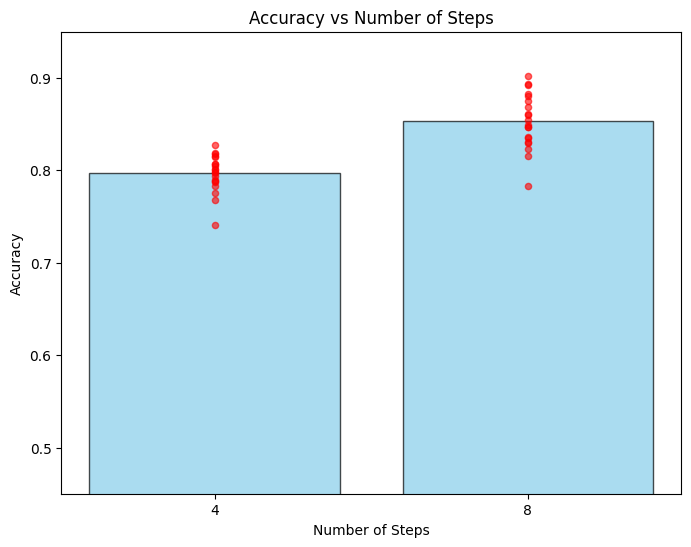

nb_steps
4    0.796857
8    0.853250
Name: agent_perf, dtype: float64

In [232]:
import matplotlib.pyplot as plt

# Group by number of steps and calculate mean accuracy
grouped = aggdf.groupby('nb_steps')['agent_perf'].mean()

# Create bar plot
plt.figure(figsize=(8, 6))
bars = plt.bar([0, 1], grouped.values, alpha=0.7, color='skyblue', edgecolor='black')

# Add individual points
for pos,nb_steps in zip([0, 1], aggdf['nb_steps'].unique()):
    step_data = aggdf[aggdf['nb_steps'] == nb_steps]['agent_perf']
    x_positions = [pos] * len(step_data)
    plt.scatter(x_positions, step_data, alpha=0.6, color='red', s=20)

plt.xlabel('Number of Steps')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Number of Steps')
plt.xticks([0, 1], ['4', '8'])
plt.ylim(0.45, .95)
plt.show()

# Also display the grouped means
grouped

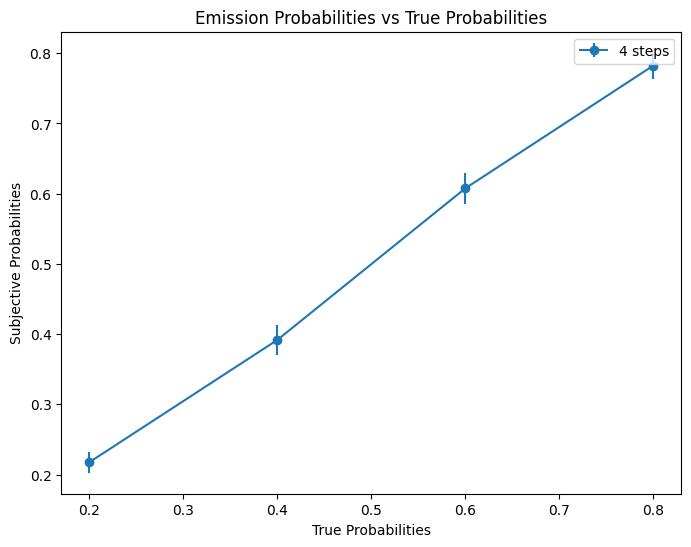

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate mean and SEM across idx_simul for each nb_steps and probas combination
plot_data = aggprobadf.groupby(['nb_steps', 'probas']).agg({
    'emission_probs': ['mean', 'std']
}).reset_index()

# Flatten column names
plot_data.columns = ['nb_steps', 'probas', 'emission_probs_mean', 'emission_probs_sem']

plt.figure(figsize=(8, 6))

# Plot for nb_steps=4
data_4 = plot_data[plot_data['nb_steps'] == 4]
plt.errorbar(data_4['probas'], data_4['emission_probs_mean'], 
             yerr=data_4['emission_probs_sem'], 
             label='4 steps', marker='o', capsize=0)

plt.xlabel('True Probabilities')
plt.ylabel('Subjective Probabilities')
plt.title('Emission Probabilities vs True Probabilities')
plt.legend()
plt.show()


In [242]:
subdata = plot_data[plot_data.nb_steps == 4]
subdata

coef_4_mean = subdata.emission_probs_mean.values
coef_4_std = subdata.emission_probs_sem.values

In [243]:
rewared_subjects_4 = aggdf[aggdf.nb_steps == 4].agent_perf.values
rewared_subjects_8 = aggdf[aggdf.nb_steps == 8].agent_perf.values

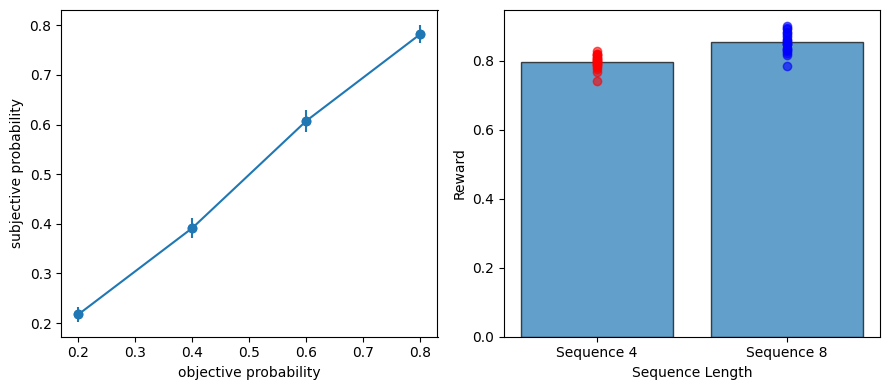

In [257]:
import matplotlib
import matplotlib.pyplot as plt

# This is the crucial line for PDF files
matplotlib.rcParams['pdf.fonttype'] = 42

# This is the equivalent for SVG files
matplotlib.rcParams['svg.fonttype'] = 'none'


plt.figure(figsize=(9, 4))
plt.subplot(1, 2, 1)
plt.scatter([0.2, 0.4, 0.6, 0.8], coef_4_mean)
plt.errorbar([0.2, 0.4, 0.6, 0.8], coef_4_mean, 
                yerr=coef_4_std, 
                label='4 steps', marker='o', capsize=0)
plt.ylabel('subjective probability')
plt.xlabel('objective probability')
plt.subplot(1, 2, 2)
plt.bar(['Sequence 4', 'Sequence 8'], [np.mean(rewared_subjects_4), np.mean(rewared_subjects_8[rewared_subjects_4 > 0.5])], alpha=0.7, edgecolor='black')
plt.scatter(['Sequence 4'] * len(rewared_subjects_4), rewared_subjects_4, alpha=0.6, color='red')
plt.scatter(['Sequence 8'] * len(rewared_subjects_8), rewared_subjects_8, alpha=0.6, color='blue')
plt.ylabel('Reward')
plt.xlabel('Sequence Length')
plt.tight_layout()
plt.savefig('/Users/csmfindling/Documents/Postdoc-Geneva/reliability_VW/expe/fig/subjects/performance_neuralHMM.pdf')
plt.show()


In [127]:
[probas[::-1], probas]

[array([0.8, 0.6, 0.4, 0.2]), array([0.2, 0.4, 0.6, 0.8])]